In [5]:
import pandas as pd 
import matplotlib.pyplot as plt 
import numpy as np 
import seaborn as sns 

In [2]:
df=pd.read_csv('weight-height.csv')

In [3]:
df

,Gender,Height,Weight
0,Male,73.847017,241.893563
1,Male,68.781904,162.310473
2,Male,74.110105,212.740856
3,Male,71.730978,220.042470
4,Male,69.881796,206.349801
...,...,...,...
9995,Female,66.172652,136.777454
9996,Female,67.067155,170.867906
9997,Female,63.867992,128.475319
9998,Female,69.034243,163.852461


In [4]:
df['Height'].describe()

count    10000.000000
mean        66.367560
std          3.847528
min         54.263133
25%         63.505620
50%         66.318070
75%         69.174262
max         78.998742
Name: Height, dtype: float64

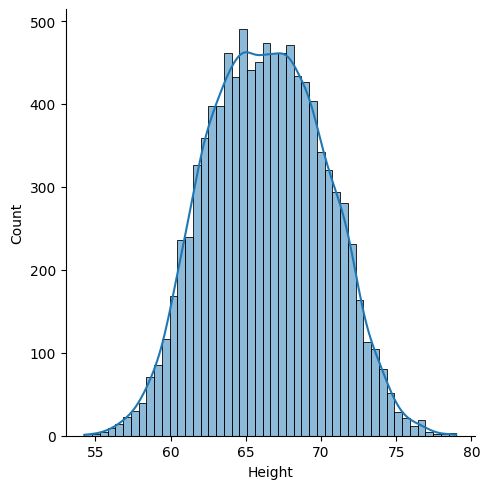

In [7]:
sns.displot(df['Height'],kde=True)

<Axes: xlabel='Height'>

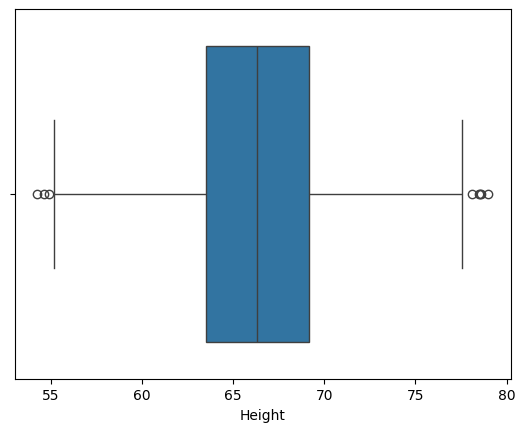

In [14]:
sns.boxplot(df['Height'],orient='h')

In [9]:
upper_limit=df['Height'].quantile(0.99)
upper_limit

np.float64(74.7857900583366)

In [12]:
lower_limit=df['Height'].quantile(0.01)
lower_limit

np.float64(58.13441158671655)

# triming 

In [16]:
df[(df['Height']>upper_limit)|(df['Height']<lower_limit)]

,Gender,Height,Weight
23,Male,75.205974,228.761781
190,Male,76.709835,235.035419
197,Male,75.944460,231.924749
202,Male,75.140821,224.124271
215,Male,74.795375,232.635403
...,...,...,...
9761,Female,56.975279,90.341784
9825,Female,55.979198,85.417534
9895,Female,57.740192,93.652957
9904,Female,57.028857,101.202551


In [19]:
new_df=df[(df['Height']<upper_limit)&(df['Height']>lower_limit)]

In [20]:
new_df

,Gender,Height,Weight
0,Male,73.847017,241.893563
1,Male,68.781904,162.310473
2,Male,74.110105,212.740856
3,Male,71.730978,220.042470
4,Male,69.881796,206.349801
...,...,...,...
9995,Female,66.172652,136.777454
9996,Female,67.067155,170.867906
9997,Female,63.867992,128.475319
9998,Female,69.034243,163.852461


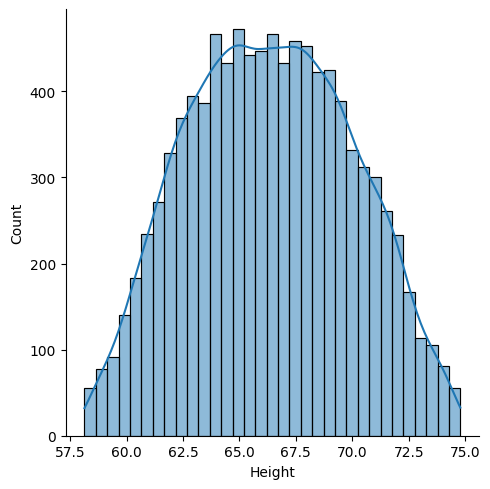

In [21]:
sns.displot(new_df['Height'],kde=True)

Text(0.5, 1.0, 'before trimming ')

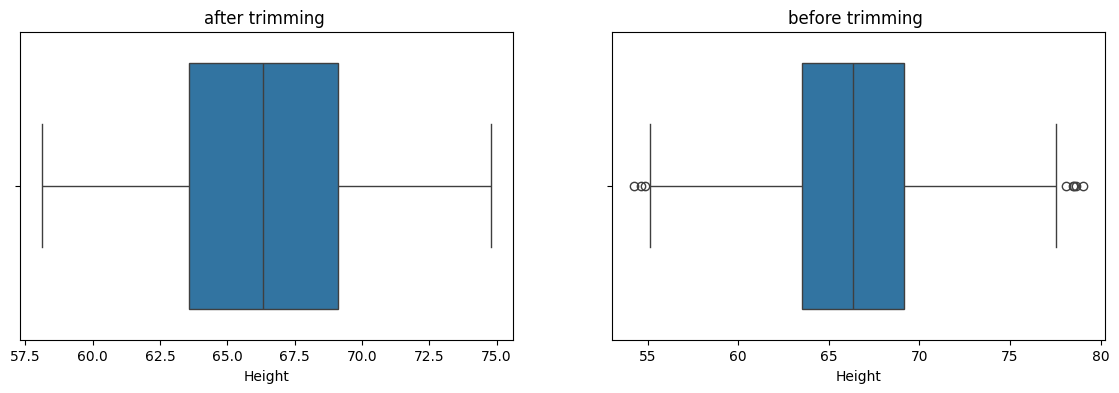

In [26]:
plt.figure(figsize=(14,4))
plt.subplot(121)
sns.boxplot(new_df['Height'],orient='h')
plt.title('after trimming ')
plt.subplot(122)
sns.boxplot(df['Height'],orient='h')
plt.title('before trimming ')

# capping -- winsorization

In [28]:
df['Height']=np.where(
    df['Height']>upper_limit,
    upper_limit,
    np.where(
        df['Height']<lower_limit,
        lower_limit,
        df['Height']
    )
)

In [30]:
df.shape

(10000, 3)

In [31]:
df.describe()

,Height,Weight
count,10000.000000,10000.000000
mean,66.366281,161.440357
std,3.795717,32.108439
min,58.134412,64.700127
25%,63.505620,135.818051
50%,66.318070,161.212928
75%,69.174262,187.169525
max,74.785790,269.989699


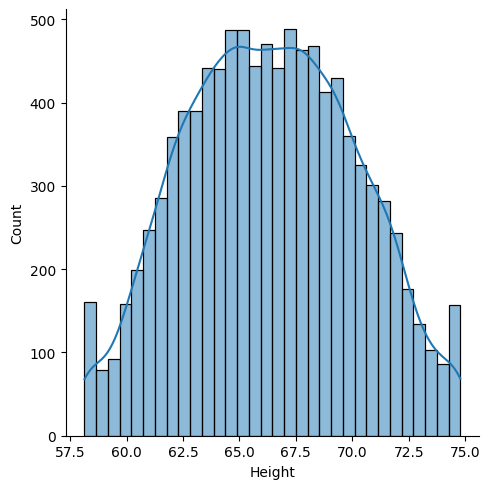

In [33]:
sns.displot(df['Height'],kde=True)

<Axes: xlabel='Height'>

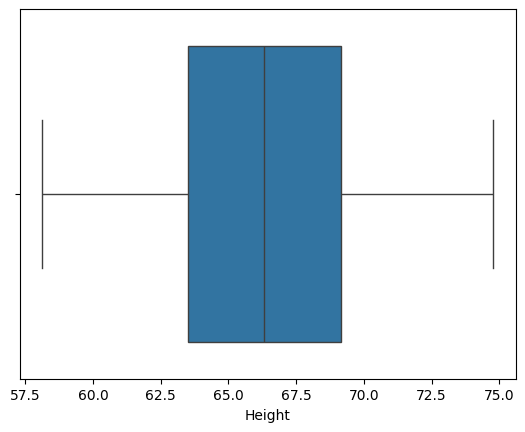

In [34]:
sns.boxplot(df['Height'],orient='h')

In [35]:
# outlier remove in both techniques trimming and capping 